# Schatveld — Minecraft via Modrinth (puur Minecraft)
Een schatgraaf-rollenspel op het échte marschland van **Weddewarden / Land Wursten**
(Bremerhaven-Nord), volledig in **Minecraft Java 1.21.10** met **Modrinth-mods**, een
**datapack** en een **Python-regelmotor** ("brain") die de vondsten bepaalt.

Dit notebook genereert alles met Python, bouwt de wereld live op een Fabric-server, en
legt uit **welke assets** je installeert en **hoe je verbindt** (incl. de Iris-shader-
workaround voor Apple Silicon).

In [1]:
import subprocess, sys, os, socket, glob
ROOT = r"/Users/develuse/Documents/schatveld"
def run(*args):
    r = subprocess.run([sys.executable, *args], capture_output=True, text=True, cwd=ROOT)
    print((r.stdout or r.stderr).strip()[-800:]); return r
def port_up(p):
    s = socket.socket(); s.settimeout(1)
    try: s.connect(("127.0.0.1", p)); return True
    except OSError: return False
    finally: s.close()
print("werkmap:", ROOT)

werkmap: /Users/develuse/Documents/schatveld


## 1. Welke assets gebruik je?
Alles hieronder wordt automatisch met de juiste versie + sha512 uit de **Modrinth-API**
opgehaald door `datapack/build_mrpack.py`. Je hoeft niets handmatig te downloaden.

### Spelwereld — `schatveld-world-1.21.10.mrpack` (MC 1.21.10, Fabric)
| Asset | Type | Rol | Nodig? |
|---|---|---|---|
| **Fabric API** | mod (basis) | vereiste voor alle Fabric-mods | ✅ vereist |
| **BetterArcheology** | mod (gameplay) | borstels, verdachte blokken — past perfect bij het graven | ✅ aanbevolen |
| **Sodium** | mod (render) | vloeiende framerate | ✅ client |
| **Lithium** | mod (tick) | server-/wereldsimulatie sneller | ✅ |
| **FerriteCore** | mod (geheugen) | minder RAM-gebruik | ⭘ optioneel |
| **EntityCulling** | mod (render) | rendert onzichtbare entiteiten niet | ⭘ optioneel |
| **Entity Model Features (EMF)** | mod (render) | custom entiteit-modellen | ⭘ optioneel |
| **Entity Texture Features (ETF)** | mod (render) | custom entiteit-texturen (+ Fresh Animations) | ⭘ optioneel |
| **Schatveld-datapack** | datapack | 0–100 per blok, graven emit → brain-loot | ✅ vereist |
| **Schatveld resource pack** | resource pack | metaaldetector + vondst-texturen (barnsteen, fibula, munt, ploegijzer, potscherf) | ✅ aanbevolen |

### Shaders (Apple Silicon) — `schatveld-shaders-1.20.1.mrpack` (MC 1.20.1)
| Asset | Versie | Rol |
|---|---|---|
| **Iris** | 1.6.17 | shader-loader die nog op **OpenGL 4.1** draait (≥1.7 eist 4.3 → crasht op Mac) |
| **Sodium** | 0.5.3 | past bij Iris 1.6.x |
| **Complementary Reimagined** | r5.8.1 | de shaderpack (4.1-compatibel) |

> **Waarom twee packs?** macOS geeft max **OpenGL 4.1** (Apple heeft OpenGL bevroren — niet
> te upgraden). De spelwereld draait daarom op 1.21.10 **zónder** Iris (Sodium + EMF/ETF +
> resource pack geven de upgrade); voor échte shaders gebruik je de 1.20.1-pack.

## 2. Genereer de distributie met Python

In [2]:
run(os.path.join(ROOT,"datapack","build_datapack.py"))
run(os.path.join(ROOT,"resourcepack","build_resourcepack.py"))
run(os.path.join(ROOT,"datapack","build_mrpack.py"))
for f in sorted(glob.glob(os.path.join(ROOT,"datapack","build","*.mrpack"))
                + glob.glob(os.path.join(ROOT,"resourcepack","build","*.zip"))):
    print("  ->", os.path.relpath(f, ROOT), os.path.getsize(f), "bytes")

datapack -> /Users/develuse/Documents/schatveld/datapack/build/schatveld_datapack.zip 8251 bytes
mrpack   -> /Users/develuse/Documents/schatveld/datapack/build/schatveld.mrpack 5825 bytes


resource pack -> /Users/develuse/Documents/schatveld/resourcepack/build/schatveld_resources.zip  (7 vondst-texturen + icoon)


 mod  ferrite-core           6.0.1
   mod  entityculling          1.10.5
   shad complementary-reimagined r5.8.1
-> /Users/develuse/Documents/schatveld/datapack/build/schatveld-shaders-1.20.1.mrpack  (7 downloads, 1 overrides)

[2/2] Rijkere spelwereld (MC 1.21.10, brain-game + BetterArcheology)
   mod  fabric-api             0.138.4+1.21.10
   mod  sodium                 mc1.21.10-0.7.3-fabric
   mod  lithium                mc1.21.10-0.20.1-fabric
   mod  ferrite-core           8.1.0-fabric
   mod  entityculling          1.10.5
   mod  entity-model-features  3.2.4-fabric-1.21.9
   mod  entitytexturefeatures  7.1-fabric-1.21.9
   mod  better-archeology      1.21.10-1.3.4
-> /Users/develuse/Documents/schatveld/datapack/build/schatveld-world-1.21.10.mrpack  (8 downloads, 2 overrides)

klaar.
  -> datapack/build/schatveld-shaders-1.20.1.mrpack 1878 bytes
  -> datapack/build/schatveld-world-1.21.10.mrpack 9272 bytes
  -> datapack/build/schatveld.mrpack 5825 bytes
  -> resourcepack/build/sc

## 3. Importeer in de Modrinth-launcher
1. Open de **Modrinth App** → **+ Add instance → From file**.
2. Kies `datapack/build/schatveld-world-1.21.10.mrpack` (de spelwereld) — of
   `datapack/build/schatveld-shaders-1.20.1.mrpack` voor shaders.
3. De launcher downloadt alle mods/shaderpack automatisch (versies uit stap 2).
4. **Play** het profiel.

*(Bestaat al op deze pc?* Het profiel **`chemlab`** draait MC 1.21.10 Fabric met precies
deze mods — dat kun je meteen gebruiken.)

## 4. Start de server-backend
Draai in een **terminal** (blokkeert):
```
bash pybrain/play.sh      # Fabric-server + Python-brain + brug, met de marsch al gebouwd
```

In [3]:
for name, p in [("Fabric-server (RCON)",25575), ("Minecraft (join)",25565), ("brain",8791)]:
    print(f"  {'✓' if port_up(p) else '·'} {name}: poort {p} {'UP' if port_up(p) else 'down — start pybrain/play.sh'}")

  ✓ Fabric-server (RCON): poort 25575 UP
  ✓ Minecraft (join): poort 25565 UP
  ✓ brain: poort 8791 UP


## 5. Bouw het marschland live (RCON) + verifieer

In [4]:
if port_up(25575):
    run(os.path.join(ROOT,"pybrain","build_marsh.py"), "0", "0")
else:
    print("(geen server — start pybrain/play.sh en her-run)")

Bouw marschland bij oorsprong (0,0) …
   35 /fill+/setblock-opdrachten uitgevoerd (48×36 blokken, 5 details).
Verificatie (execute if block):
   [v] Watt-water westrand    @(1,63,5) = minecraft:water  ::  Test passed
   [v] Deich-gras             @(3,66,5) = minecraft:grass_block  ::  Test passed
   [v] Graben-water           @(12,63,10) = minecraft:water  ::  Test passed
   [v] Wurt-gras              @(7,65,24) = minecraft:grass_block  ::  Test passed
   [v] boerderij-dak          @(11,69,27) = minecraft:dark_oak_planks  ::  Test passed
-> 5/5 steekproeven kloppen.


## 6. Bewijs: de Python-brain bepaalt de vondst
De datapack stuurt een graaf-event; de brain rekent de vondst (deterministisch veld
0–100, **< 10 = altijd roestig ijzer**) en geeft het item met deeltjes, geluid en een
actionbar-melding.

In [5]:
sys.path.insert(0, os.path.join(ROOT,"pybrain"))
if port_up(25575):
    from rcon import Rcon
    import mc_bridge
    from schatveld_core import Brain, field
    with Rcon(port=25575, password="schatveld", timeout=5) as rc:
        rc.command('data modify storage schatveld:ev queue append value {kind:"dig",Pos:[7.5d,64.0d,7.5d]}')
        out = rc.command("data get storage schatveld:ev queue")
        b = Brain()
        for (k,x,y,z) in mc_bridge.parse_queue(out):
            print("Minecraft-dig ->", mc_bridge.handle_event(b, rc, k, x, y, z))
        rc.command("data modify storage schatveld:ev queue set value []")
    print("field.value(7,7) =", field.value(7,7), "(deterministisch, = de datapack-hash)")
else:
    print("(geen server — sla over)")

Minecraft-dig -> ('dig', 84, 'Handgesmede spijkers')
field.value(7,7) = 84 (deterministisch, = de datapack-hash)


## 7. Verbind en speel
In-game: **Multiplayer → Direct Connection →** `localhost` → **Join**. Je spawnt op het
marschland: **Deich · Wurt + boerderij · Gräben · gewaspercelen**. Typ
`/function schatveld:menu` voor je rol + schep + metaaldetector.

- **Metaaldetector**: rechtsklik grond → metaalwaarde **0–100**.
- **Graven**: de brain bepaalt de vondst; **< 10 = altijd roestig ijzer**, hoger = agrarisch
  ijzer / munten / (zeldzaam) barnsteen, fibula, Wurt-artefact. Significante vondsten vallen
  onder het **Schatzregal** (staatsbezit → vindersloon). Zonder **Nachforschungsgenehmigung**
  is graven *Raubgrabung*.

## 8. Demonstratie-render van de gebouwde wereld

iso-render -> /Users/develuse/Documents/schatveld/data/schatveld_marsh_iso.png (897x495)


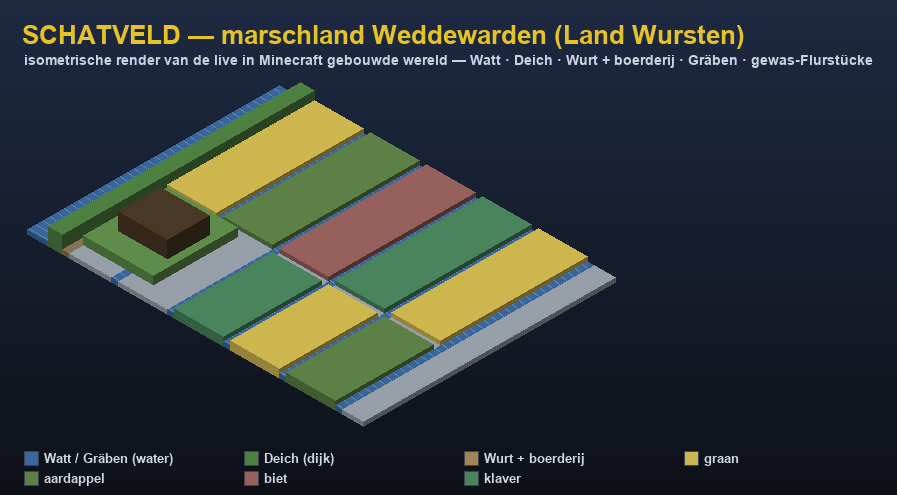

In [6]:
run(os.path.join(ROOT,"data","render_marsh_iso.py"))
from IPython.display import Image
Image(filename=os.path.join(ROOT,"data","schatveld_marsh_iso.png"))

## Klaar
Stoppen: `bash pybrain/stop.sh` · opnieuw: `bash pybrain/play.sh`.
Puur Minecraft — datapack + Modrinth-mods + Python-brain, geen extra client nodig.